In [1]:
import pyvisa as visa
from time import sleep
import matplotlib.pyplot as plt
import numpy as np
import time
import matplotlib.dates as mdates
import os
import pandas as pd
from datetime import datetime, timedelta
from edes.modules.detection.detection_utils import plot, plot_ax, big_plt_font
big_plt_font()

import requests
import json

In [2]:
T_to_channels = {'40K': 1, '4K': 2, '0.4K': 5}
CH_to_T = {1: 40, 2: 4, 5: 0.4}

In [3]:
## Get latest measurement
req = requests.get('http://169.254.168.2:5001/channel/measurement/latest', timeout=10)
data = req.json()
print('Response: \n{}'.format(json.dumps(data, indent=2)))

Response: 
{
  "channel_nr": 1,
  "temperature": 293.291581,
  "resistance": 108.046,
  "reactance": -114748.269,
  "angle": 90.053,
  "magnitude": 108.046,
  "rez": 108.046,
  "imz": -0.101,
  "settings_nr": 17,
  "status_flags": [],
  "timestamp": 1771028043.724944,
  "datetime": "2026-02-14T00:14:04.988199Z",
  "status": "OK"
}


In [4]:
## Retrieving data directly from device
DEVICE_IP = '169.254.168.2'
# Timeout for get/post operations (in seconds)
TIMEOUT = 100
# --- Read channel N old measurement data in defined time period
#
url = 'http://{}:5001/channel/historical-data'.format(DEVICE_IP)
data = {
 'channel_nr': 1, 'start_time': '2025-12-15T00:00:00Z', 'stop_time': '2026-12-26T00:00:00Z', 'fields': ['temperature']
}
#
req = requests.post(url, json=data, timeout=TIMEOUT)
data = req.json()
#
print('Response: \n{}'.format(json.dumps(data, indent=2)))

Response: 
{
  "channel_nr": 1,
  "start_time": "2025-12-15T00:00:00Z",
  "stop_time": "2026-12-26T00:00:00Z",
  "fields": [
    "timestamp",
    "temperature"
  ],
  "measurements": null,
  "over_limit": true,
  "datetime": "2026-02-14T00:14:12.258003Z",
  "status": "OK"
}


In [5]:
def get_cryostat_data(root_dir, channel, start_date_str, end_date_str):
    """
    Parses Bluefors .log files using the YY-MM-DD format.
    """
    # Keep inputs as YYYY-MM-DD for standard processing
    start_dt = datetime.strptime(start_date_str, "%Y-%m-%d")
    end_dt = datetime.strptime(end_date_str, "%Y-%m-%d")
    
    all_timestamps = []
    all_temperatures = []
    
    current_dt = start_dt
    while current_dt <= end_dt:
        # Convert to the two-digit year format: '25-12-01'
        short_date = current_dt.strftime("%y-%m-%d")
        
        # Build the path: [root]/25-12-01/CH 1 T 25-12-01.log
        folder_path = os.path.join(root_dir, short_date)
        file_name = f"CH{channel} T {short_date}.log"
        full_path = os.path.join(folder_path, file_name)
        
        
        if os.path.exists(full_path):
            try:
                # Use low_memory=False for speed with large logs
                df = pd.read_csv(full_path, header=None, names=['date', 'time', 'temp'])
                # Combine '25-12-01' and '00:00:12' into a single datetime object
                # We specify the format explicitly to ensure '25' is read as '2025'
                df['dt_obj'] = pd.to_datetime(
                    df['date'] + ' ' + df['time'], 
                    format='%d-%m-%y %H:%M:%S'
                )
                
                all_timestamps.extend(df['dt_obj'].values)
                all_temperatures.extend(df['temp'].values)
                
            except Exception as e:
                print(f"Skipping {file_name} due to error: {e}")
        
        current_dt += timedelta(days=1)

    # Convert back to numpy arrays for the final output
    return np.array(all_timestamps), np.array(all_temperatures)

In [6]:
def plot_cryo_data_ax(ax, timestamps, temperatures, channel_name="CH1"):
    # 1. Downsampling (Optional but recommended)
    # Only plot every 100th point to keep the UI snappy
    # For a 3-month range, 1 point every few minutes is usually plenty.
    stride = 100 
    t_plot = timestamps[::stride]
    temp_plot = temperatures[::stride]
    
    # 2. The Actual Plot
    ax.plot(t_plot, temp_plot, '.--', color='#007acc', linewidth=1.5, label=f'Temp {channel_name}')
    
    # 3. Making the Time Axis "Nice"
    # This automatically picks the best interval (Months, Weeks, or Days)
    locator = mdates.AutoDateLocator(minticks=5, maxticks=12)
    formatter = mdates.ConciseDateFormatter(locator)
    
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    
    # 4. Aesthetics
    ax.set_ylabel('Temperature (K)', fontweight='bold')
    ax.set_title(f'{channel_name}', fontsize=14, pad=15)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # If looking at base temps (mK) and room temps (300K) simultaneously, 
    # a log scale is often much more informative:
    # ax.set_yscale('log') 
    
    plt.tight_layout()

In [9]:
def query_temp(stage, T_to_channels = {'40K': 1, '4K': 2, '0.4K': 5}): 
    req = requests.get('http://169.254.168.2:5001/channel/measurement/latest', timeout=10)
    data = req.json()
    ch = T_to_channels[stage]
    while data['channel_nr'] != ch: 
        req = requests.get('http://169.254.168.2:5001/channel/measurement/latest', timeout=10)
        data = req.json()
    return data['temperature']

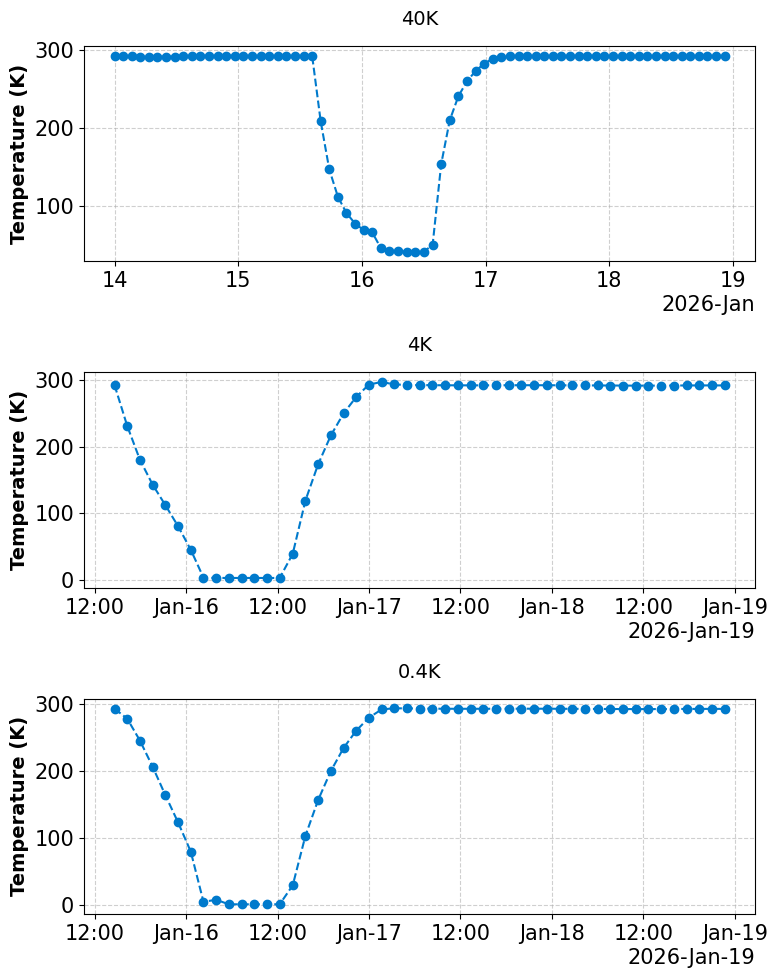

In [7]:
LOG_DIR = r"C:\Users\elect\Bluefors logs" # Use raw string (r'') for Windows paths
START_DATE = '2026-01-14'
END_DATE = '2026-01-18'
CHs = [i for i in CH_to_T]
# Run the parser
fig, ax = plt.subplots(figsize=(8,10), nrows=3)
for i in range(3):
    CH = CHs[i]
    timestamps, temperatures = get_cryostat_data(LOG_DIR, CH, START_DATE, END_DATE)
    plot_cryo_data_ax(ax[i], timestamps, temperatures, channel_name=f"{CH_to_T[CH]}K")
plt.show()

In [14]:
t0 = time.time()
T1_all, T2_all, t = [], [], []
while (time.time()-t0) < 5*60: 
    T1 = query_temp("0.4K") 
    T2 = query_temp("4K")
    print(T1, T2, time.ctime(time.time())) 
    T1_all.append(T1) 
    T2_all.append(T2) 
    t.append(time.time()-t0)
    time.sleep(1)

4.008904 3.131754 Wed Feb 18 14:14:22 2026
4.046654 3.131689 Wed Feb 18 14:14:56 2026
4.054971 3.137369 Wed Feb 18 14:15:30 2026
4.059524 3.136466 Wed Feb 18 14:16:04 2026
4.0611 3.138551 Wed Feb 18 14:16:39 2026
4.062939 3.138781 Wed Feb 18 14:17:13 2026
4.063902 3.137073 Wed Feb 18 14:17:47 2026
4.062632 3.135826 Wed Feb 18 14:18:22 2026
4.05948 3.137878 Wed Feb 18 14:18:56 2026


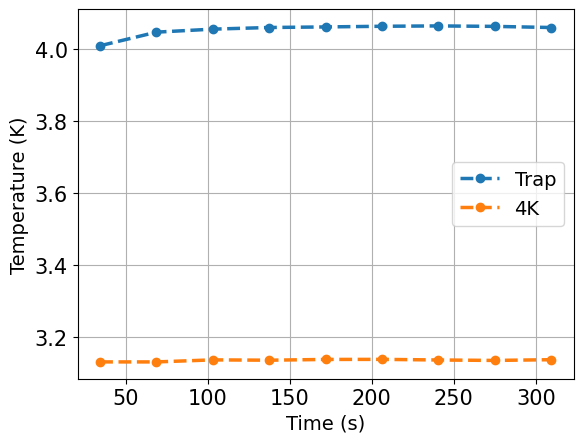

In [15]:
plot(t, T1_all, '.--', label='Trap')
plot(t, T2_all, '.--', label='4K', xlabel='Time (s)', ylabel='Temperature (K)')
plt.legend()